<a href="https://colab.research.google.com/github/PabloShol/simulacion2/blob/main/Proyecto_Ajuste_de_parametros_del_modelo_SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. GRAFICA DE LOS DATOS

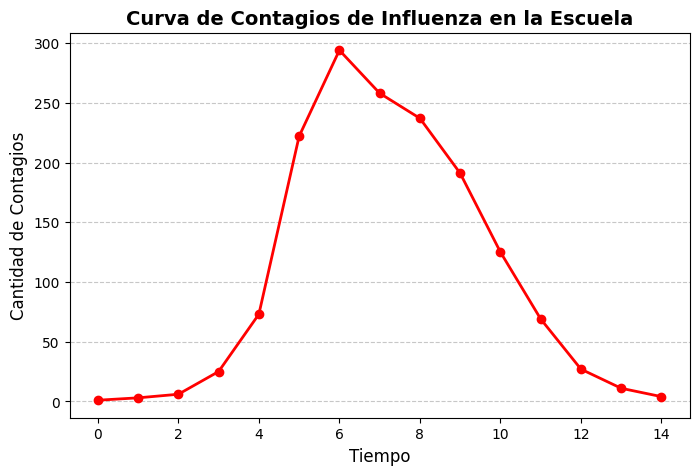

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

datos = {
    'Tiempo': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],
    'Contagios': [1,3,6,25,73,222,294,258,237,191,125,69,27,11,4]
}

df = pd.DataFrame(datos)

plt.figure(figsize=(8, 5))
plt.plot(df['Tiempo'], df['Contagios'], marker='o', color='red', linestyle='-', linewidth=2)

plt.title('Curva de Contagios de Influenza en la Escuela', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Cantidad de Contagios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 2. PROGRAMAR LA SOLUCION DEL MODELO SIR, CON PARAMETROS LIBRES

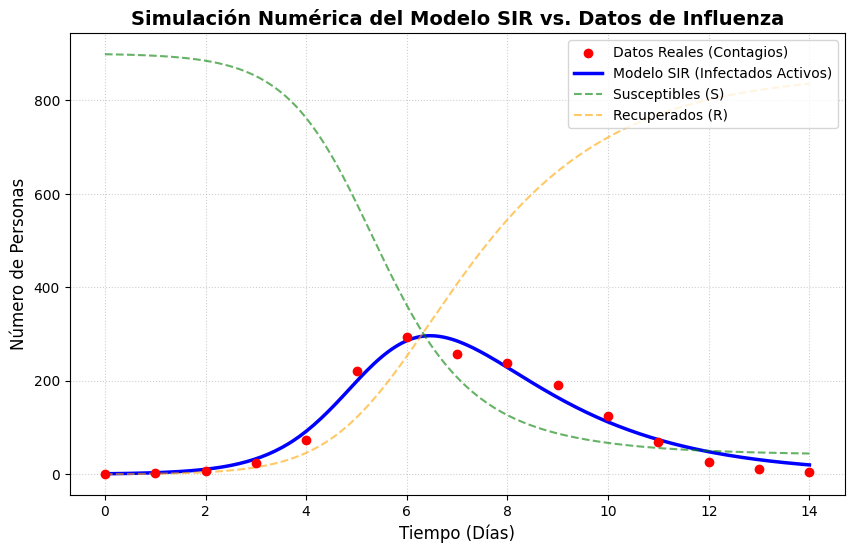

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

tiempo_real = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
contagios_real = np.array([1,3,6,25,73,222,294,258,237,191,125,69,27,11,4])

# Definición de Parámetros Libres del Modelo SIR (Modifica estos valores)
N = 900          # Población total estimada de la escuela
beta = 1.72      # Tasa de transmisión
gamma = 0.53     # Tasa de recuperación (1 / días promedio de enfermedad)

I0 = contagios_real[0]  # Infectados iniciales (1)
S0 = N - I0             # Susceptibles iniciales
R0 = 0                  # Recuperados iniciales
y0 = [S0, I0, R0]


# Definición del sistema de ecuaciones diferenciales del modelo SIR
def modelo_sir(t, y, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - (gamma * I)
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solución numérica del modelo en el rango de tiempo
t_span = (tiempo_real[0], tiempo_real[-1])
t_eval = np.linspace(tiempo_real[0], tiempo_real[-1], 200)
solucion = solve_ivp(modelo_sir, t_span, y0, args=(beta, gamma, N), t_eval=t_eval)

plt.figure(figsize=(10, 6))

plt.scatter(tiempo_real, contagios_real, color='red', label='Datos Reales (Contagios)', zorder=5)

plt.plot(solucion.t, solucion.y[1], color='blue', linewidth=2.5, label='Modelo SIR (Infectados Activos)')
plt.plot(solucion.t, solucion.y[0], color='green', linestyle='--', alpha=0.6, label='Susceptibles (S)')
plt.plot(solucion.t, solucion.y[2], color='orange', linestyle='--', alpha=0.6, label='Recuperados (R)')

plt.title('Simulación Numérica del Modelo SIR vs. Datos de Influenza', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Días)', fontsize=12)
plt.ylabel('Número de Personas', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')

plt.show()

# 3. PLANTEAR UN AJUSTE POR MINIMOS CUADRADOS $\chi^2 (a,b) $

--- PARAMETROS ÓPTIMOS ENCONTRADOS ---
Tasa de transmisión (Beta): 1.7422
Tasa de recuperación (Gamma): 0.5523
Población total estimada (N): 943 personas
R0 calculado (Beta/Gamma): 3.15



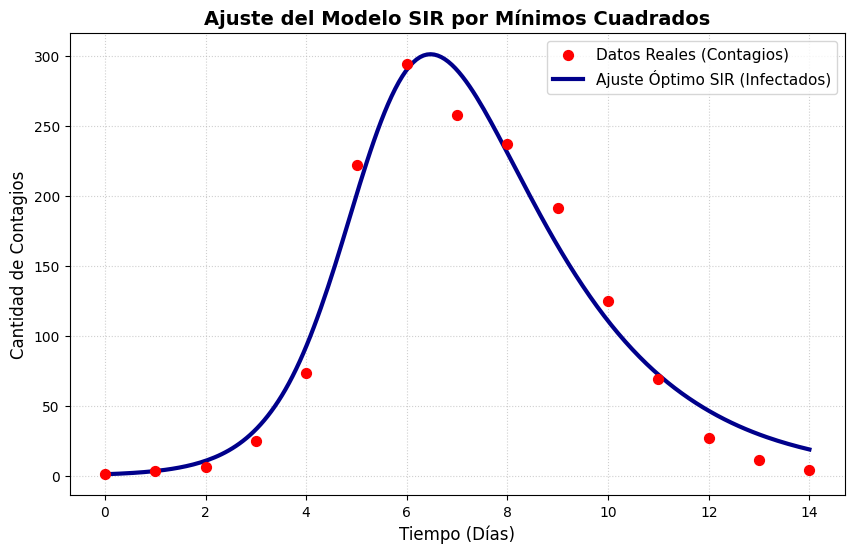

In [ ]:
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# Función objetivo de mínimos cuadrados (Residuales al cuadrado)
def funcion_objetivo(parametros):
    beta, gamma, N = parametros
    I0 = contagios_real[0]
    y0 = [N - I0, I0, 0]

    # Resolver numéricamente para los puntos de tiempo reales
    sol = solve_ivp(modelo_sir, (tiempo_real[0], tiempo_real[-1]), y0, args=(beta, gamma, N), t_eval=tiempo_real)

    if sol.status != 0:
        return 1e10 # Penalización si el integrador falla

    I_predicho = sol.y[1]

    # Suma de errores al cuadrado entre predicción y realidad
    return np.sum((I_predicho - contagios_real) ** 2)

# Optimización (Ajuste numérico)
# Estimaciones iniciales: [beta, gamma, N]
valores_iniciales = [1.5, 0.5, 1000]
# Límites lógicos para la búsqueda para evitar valores negativos o infactibles
limites = [(0.1, 5.0), (0.1, 2.0), (400, 5000)]

resultado = minimize(funcion_objetivo, valores_iniciales, bounds=limites, method='L-BFGS-B')
beta_opt, gamma_opt, N_opt = resultado.x

print("--- PARAMETROS ÓPTIMOS ENCONTRADOS ---")
print(f"Tasa de transmisión (Beta): {beta_opt:.4f}")
print(f"Tasa de recuperación (Gamma): {gamma_opt:.4f}")
print(f"Población total estimada (N): {int(N_opt)} personas")
print(f"R0 calculado (Beta/Gamma): {beta_opt/gamma_opt:.2f}\n")

# Generar curvas continuas con los parámetros óptimos
t_curva = np.linspace(tiempo_real[0], tiempo_real[-1], 200)
y0_opt = [N_opt - contagios_real[0], contagios_real[0], 0]
sol_opt = solve_ivp(modelo_sir, (tiempo_real[0], tiempo_real[-1]), y0_opt, args=(beta_opt, gamma_opt, N_opt), t_eval=t_curva)

# Graficar el resultado del ajuste
plt.figure(figsize=(10, 6))
plt.scatter(tiempo_real, contagios_real, color='red', marker='o', s=50, label='Datos Reales (Contagios)', zorder=5)
plt.plot(sol_opt.t, sol_opt.y[1], color='darkblue', linewidth=3, label='Ajuste Óptimo SIR (Infectados)')

plt.title('Ajuste del Modelo SIR por Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Días)', fontsize=12)
plt.ylabel('Cantidad de Contagios', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()


# 4. USAR EL METODO MCMC (Metropolis-Hastings) para optimizar $\chi^2$

<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:72: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_576/2173624759.py:72: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Ajuste del Modelo SIR usando MCMC minimizando $\chi^2$', fontsize=14, fontweight='bold')


Ejecutando MCMC (Metropolis-Hastings)... Por favor espera unos segundos.
Tasa de aceptación del MCMC: 0.70%

--- PARÁMETROS ÓPTIMOS ENCONTRADOS VÍA MCMC ---
Beta estimado: 1.7315
Gamma estimado: 0.5368
Población N estimada: 917 personas
R0 (MCMC): 3.23



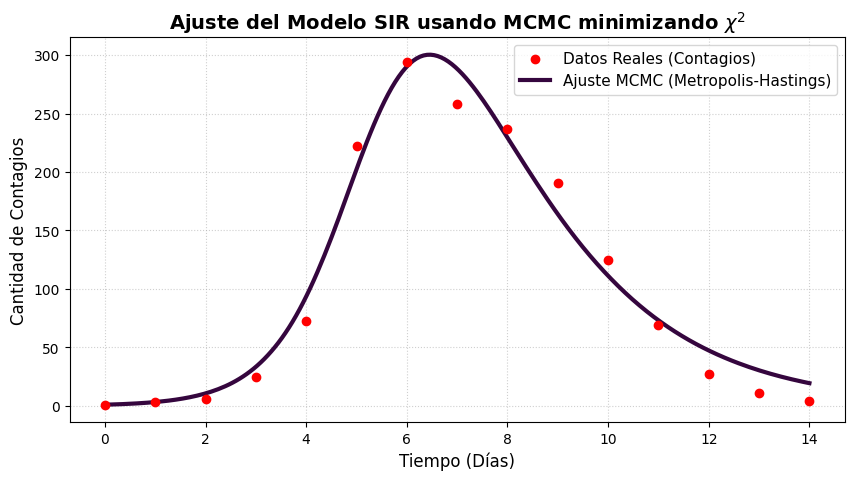

In [ ]:
sigma = np.sqrt(contagios_real)
sigma[sigma == 0] = 1.0

# Algoritmo de Metropolis-Hastings (MCMC)
def metropolis_hastings(n_pasos=10000):
    # Punto de partida en el espacio de parámetros [beta, gamma, N]
    param_actual = np.array([1.5, 0.5, 1000.0])
    chi2_actual = funcion_objetivo(param_actual)

    # Desviaciones estándar para dar los "pasos" aleatorios (Paso de propuesta)
    propuesta_sigma = np.array([0.02, 0.01, 15.0])

    cadenas = []
    aceptados = 0

    for paso in range(n_pasos):
        # Proponer nuevos parámetros sumando ruido gaussiano
        param_propuesto = param_actual + np.random.normal(0, propuesta_sigma)
        chi2_propuesto = funcion_objetivo(param_propuesto)

        # Evaluar la probabilidad de aceptación basada en Delta Chi2
        # Recordando que Probabilidad ~ exp(-Chi2 / 2)
        delta_chi2 = chi2_propuesto - chi2_actual

        if delta_chi2 < 0:
            # Si el Chi2 disminuye, el paso mejora el ajuste; se acepta automáticamente
            aceptar = True
        else:
            # Si el Chi2 aumenta, se acepta probabilísticamente según el criterio de Metropolis
            probabilidad_aceptacion = np.exp(-0.5 * delta_chi2)
            aceptar = np.random.rand() < probabilidad_aceptacion

        if aceptar:
            param_actual = param_propuesto
            chi2_actual = chi2_propuesto
            aceptados += 1

        cadenas.append(param_actual)

    print(f"Tasa de aceptación del MCMC: {(aceptados / n_pasos) * 100:.2f}%")
    return np.array(cadenas)

# Ejecutar la cadena MCMC
print("Ejecutando MCMC (Metropolis-Hastings)... Por favor espera unos segundos.")
np.random.seed(42) # Para reproducibilidad
num_iteraciones = 12000
cadena = metropolis_hastings(n_pasos=num_iteraciones)

# Descartar el primer 20% de los pasos (Periodo de calentamiento / Burn-in)
burn_in = int(num_iteraciones * 0.2)
cadena_estable = cadena[burn_in:]

# Calcular los parámetros óptimos promediando la distribución posterior
beta_mcmc = np.mean(cadena_estable[:, 0])
gamma_mcmc = np.mean(cadena_estable[:, 1])
N_mcmc = np.mean(cadena_estable[:, 2])

print("\n--- PARÁMETROS ÓPTIMOS ENCONTRADOS VÍA MCMC ---")
print(f"Beta estimado: {beta_mcmc:.4f}")
print(f"Gamma estimado: {gamma_mcmc:.4f}")
print(f"Población N estimada: {int(N_mcmc)} personas")
print(f"R0 (MCMC): {beta_mcmc/gamma_mcmc:.2f}\n")

# Graficar resultados
t_curva = np.linspace(tiempo_real[0], tiempo_real[-1], 200)
y0_mcmc = [N_mcmc - contagios_real[0], contagios_real[0], 0]
sol_mcmc = solve_ivp(modelo_sir, (tiempo_real[0], tiempo_real[-1]), y0_mcmc, args=(beta_mcmc, gamma_mcmc, N_mcmc), t_eval=t_curva)

plt.figure(figsize=(10, 5))
plt.scatter(tiempo_real, contagios_real, color='red', label='Datos Reales (Contagios)', zorder=5)
plt.plot(t_curva, sol_mcmc.y[1], color='#35063E', linewidth=3, label='Ajuste MCMC (Metropolis-Hastings)')
plt.title('Ajuste del Modelo SIR usando MCMC minimizando $\chi^2$', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Días)', fontsize=12)
plt.ylabel('Cantidad de Contagios', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

# 5. REPLANTEAR CON pyMC EN EL ENFOQUE BAYESIANO

/tmp/ipykernel_576/3755323167.py:11: FutureWarning: pytensor.as_op is deprecated and will be removed in a future release. Please use pytensor.wrap_py instead.
  @as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])


Iniciando el muestreo bayesiano con PyMC... (Esto puede tardar 1-2 minutos)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- RESUMEN ESTADÍSTICO DE LA POSTERIOR ---
           mean       sd   hdi_3%   hdi_97%
beta      1.779    0.081    1.658     1.948
gamma     0.595    0.096    0.439     0.776
N      1018.086  170.721  763.012  1368.053
sigma    18.630    3.785   11.922    25.051

R0 Bayesiano Promedio (Beta/Gamma): 2.99



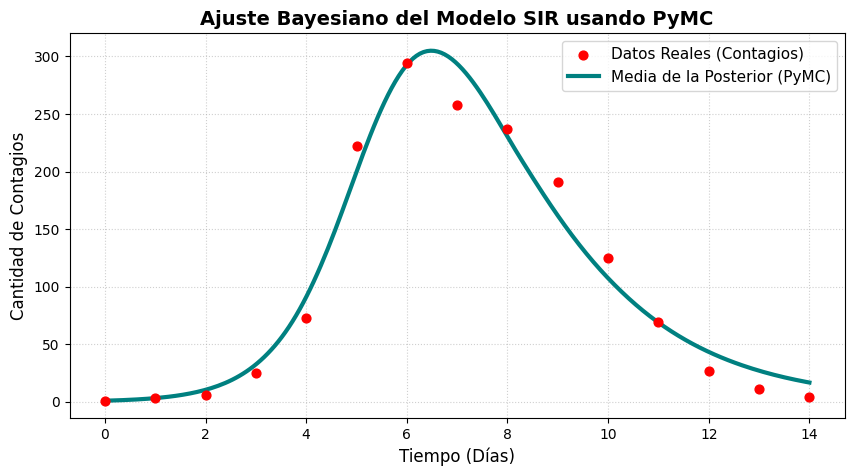

In [ ]:
import pymc as pm
import pytensor.tensor as pt
from pytensor.compile.ops import as_op

# Modelo SIR determinista (Función de SciPy envuelta para PyMC)
def ed_sir(t, y, beta, gamma, N):
    S, I, R = y
    return [-beta * S * I / N, (beta * S * I / N) - (gamma * I), gamma * I]

# Convertimos la simulación numérica en un operador compatible con PyMC usando Pytensor
@as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])
def simulacion_sir_op(beta, gamma, N):
    I0 = contagios_real[0]
    y0 = [N - I0, I0, 0.0]
    sol = solve_ivp(ed_sir, (tiempo_real[0], tiempo_real[-1]), y0, args=(beta, gamma, N), t_eval=tiempo_real)
    # Si la integración falla, devolvemos un vector de ceros para no romper la cadena
    if sol.status != 0:
        return np.zeros_like(tiempo_real)
    return sol.y[1] # Retorna únicamente la curva de Infectados (I)

# Construcción del Modelo Bayesiano en PyMC
with pm.Model() as modelo_bayesiano:

    # Prioris (Distribuciones previas basadas en conocimiento del problema)
    beta = pm.Uniform("beta", lower=0.5, upper=3.0)
    gamma = pm.Uniform("gamma", lower=0.1, upper=1.5)
    N = pm.Uniform("N", lower=500, upper=2000)

    # Desviación estándar del error de medición (Incertidumbre de los datos)
    sigma = pm.HalfNormal("sigma", sigma=15)

    # Conectar la simulación numérica del modelo SIR
    curva_infectados = simulacion_sir_op(beta, gamma, N)

    # Verosimilitud (Likelihood): Asumimos que los datos reales siguen una distribución Normal
    # centrada en la predicción del modelo SIR
    observaciones = pm.Normal("observaciones", mu=curva_infectados, sigma=sigma, observed=contagios_real)

# Muestreo de la distribución posterior (MCMC avanzado con NUTS/Metropolis)
    print("Iniciando el muestreo bayesiano con PyMC... (Esto puede tardar 1-2 minutos)")
    # Usamos step=pm.Metropolis() debido a que as_op no provee gradientes para NUTS
    trace = pm.sample(draws=2000, tune=1000, step=pm.Metropolis(), chains=2, random_seed=42)

# Extracción de estadísticas de los parámetros ajustados
summary = pm.summary(trace, var_names=["beta", "gamma", "N", "sigma"])
print("\n--- RESUMEN ESTADÍSTICO DE LA POSTERIOR ---")
print(summary[["mean", "sd", "hdi_3%", "hdi_97%"]])

beta_medio = summary.loc["beta", "mean"]
gamma_medio = summary.loc["gamma", "mean"]
N_medio = summary.loc["N", "mean"]

print(f"\nR0 Bayesiano Promedio (Beta/Gamma): {beta_medio/gamma_medio:.2f}\n")

# Graficar la solución con los parámetros del promedio posterior
t_curva = np.linspace(tiempo_real[0], tiempo_real[-1], 200)
y0_bayes = [N_medio - contagios_real[0], contagios_real[0], 0.0]
sol_bayes = solve_ivp(ed_sir, (tiempo_real[0], tiempo_real[-1]), y0_bayes, args=(beta_medio, gamma_medio, N_medio), t_eval=t_curva)

plt.figure(figsize=(10, 5))
plt.scatter(tiempo_real, contagios_real, color='red', s=40, label='Datos Reales (Contagios)', zorder=5)
plt.plot(t_curva, sol_bayes.y[1], color='teal', linewidth=3, label='Media de la Posterior (PyMC)')
plt.title('Ajuste Bayesiano del Modelo SIR usando PyMC', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Días)', fontsize=12)
plt.ylabel('Cantidad de Contagios', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()